# Sprint v6.5 — Engine Accounting: Failure Report
**Date: 2026-06-13 | Signals: RV1_A, RV2_A, RV3_A | 2007–2026 | $1M notional**

Sprint v6 factor attribution revealed that 57 % of Strategy A gross P&L came from
*model drift* — the rolling OLS intercept re-centring, not market mean reversion.
This sprint ran a rescue test: does the edge survive fixed-entry accounting?

**Finding: all three Tier 1 signals fail. Tier 1 is invalid as constructed.**

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from backtest.ab_test import build_strategy, StrategySpec, load_inputs
from execution.costs import CostParams, trade_cost

features, residuals = load_inputs()
cmd = pd.read_parquet(os.path.join(_here, 'data', 'raw', 'credit_market_data.parquet'))

NOTIONAL = 1_000_000.0
cp = CostParams()
BORROW_PER_DAY = cp.borrow_annual / 252.0 * NOTIONAL
SPREAD_SLIPPAGE = trade_cost(NOTIONAL, holding_days=0, params=cp)

idx = features.index
idx_map = {d: i for i, d in enumerate(idx)}

def sharpe(s):
    return float(s.mean() / s.std() * np.sqrt(252)) if s.std() > 0 else 0.0

def max_dd(s):
    eq = s.cumsum()
    return float((eq - eq.cummax()).min())

def fixed_daily_mtm(trades, y_arr, x_arr):
    n = len(idx)
    arr = np.zeros(n)
    for _, row in trades.iterrows():
        ei = idx_map[row['entry_fill_date']]
        xi = idx_map[row['exit_fill_date']]
        sign = int(row['side'])
        be   = row['hedge_ratio_entry']
        arr[ei] -= SPREAD_SLIPPAGE
        for d in range(ei + 1, xi + 1):
            arr[d] += sign * ((y_arr[d] - y_arr[d-1]) - be * (x_arr[d] - x_arr[d-1])) * NOTIONAL
            arr[d] -= BORROW_PER_DAY
    return pd.Series(arr, index=idx)

print("Data loaded. Engine helpers defined.")
print(f"Features: {features.shape}, index {idx[0]} → {idx[-1]}")

Data loaded. Engine helpers defined.
Features: (4784, 56), index 2007-04-11 00:00:00 → 2026-04-15 00:00:00


---
## Section 1 — RV1_A Rescue Test (T1)

Fixed-entry daily MTM: replace rolling `rv[d] - rv[d-1]` with
`(hy[d]-hy[d-1]) - β_entry × (ig[d]-ig[d-1])` on every day of the hold.
α cancels in the difference. The registered engine Sharpe (0.591) is the baseline.

In [2]:
strat1    = build_strategy(features, residuals, StrategySpec('rv_hy_ig', 'ols', gated=False))
d1_old    = strat1.daily_pnl
d1_fixed  = fixed_daily_mtm(strat1.trades,
                             features['hy_spread'].to_numpy(),
                             features['ig_spread'].to_numpy())

# Reconciliation
recon1 = sum(
    int(r['side']) * (
        (features['hy_spread'][r['exit_fill_date']] - features['hy_spread'][r['entry_fill_date']])
        - r['hedge_ratio_entry'] *
        (features['ig_spread'][r['exit_fill_date']] - features['ig_spread'][r['entry_fill_date']])
    ) * NOTIONAL - r['cost']
    for _, r in strat1.trades.iterrows()
)
assert abs(d1_fixed.sum() - recon1) < 1, f"Reconciliation failed: {abs(d1_fixed.sum()-recon1):.2f}"
print(f"Reconciliation diff: ${abs(d1_fixed.sum()-recon1):.2f}  ✓")

hit1_old   = (strat1.trades['net_pnl'] > 0).mean()
hit1_fixed = sum(
    int(r['side']) * (
        (features['hy_spread'][r['exit_fill_date']] - features['hy_spread'][r['entry_fill_date']])
        - r['hedge_ratio_entry'] *
        (features['ig_spread'][r['exit_fill_date']] - features['ig_spread'][r['entry_fill_date']])
    ) * NOTIONAL - r['cost'] > 0
    for _, r in strat1.trades.iterrows()
) / len(strat1.trades)

print()
print(f"{'metric':<28} {'registered':>14} {'corrected':>14} {'delta':>10}")
print("-" * 70)
for lbl, vo, vf in [
    ("net Sharpe",       sharpe(d1_old),    sharpe(d1_fixed)),
    ("hit rate",         hit1_old,          hit1_fixed),
    ("total net P&L $k", d1_old.sum()/1e3,  d1_fixed.sum()/1e3),
    ("max drawdown $k",  max_dd(d1_old)/1e3, max_dd(d1_fixed)/1e3),
]:
    fmt = ".3f" if "Sharpe" in lbl else (".1%" if "hit" in lbl else ",.1f")
    if "P&L" in lbl or "draw" in lbl:
        print(f"{lbl:<28} {vo:>14,.1f} {vf:>14,.1f} {vf-vo:>+10,.1f}")
    elif "hit" in lbl:
        print(f"{lbl:<28} {vo:>14.1%} {vf:>14.1%} {vf-vo:>+10.1%}")
    else:
        print(f"{lbl:<28} {vo:>14.3f} {vf:>14.3f} {vf-vo:>+10.3f}")

R1 = sharpe(d1_fixed) >= 0.40
R2 = hit1_fixed >= 0.60
print()
print(f"R1 corrected Sharpe {sharpe(d1_fixed):.3f} ≥ 0.40 : {'PASS' if R1 else 'FAIL'}")
print(f"R2 corrected hit    {hit1_fixed:.1%}  ≥ 60%  : {'PASS' if R2 else 'FAIL'}")
print()
print("GATE OPEN" if (R1 and R2) else "GATE CLOSED — Tier 1 revisit required")

Reconciliation diff: $0.00  ✓

metric                           registered      corrected      delta
----------------------------------------------------------------------
net Sharpe                            0.591          0.202     -0.389
hit rate                              80.9%          68.1%     -12.8%
total net P&L $k                      760.4          274.7     -485.6
max drawdown $k                      -152.0         -234.2      -82.2

R1 corrected Sharpe 0.202 ≥ 0.40 : FAIL
R2 corrected hit    68.1%  ≥ 60%  : PASS

GATE CLOSED — Tier 1 revisit required


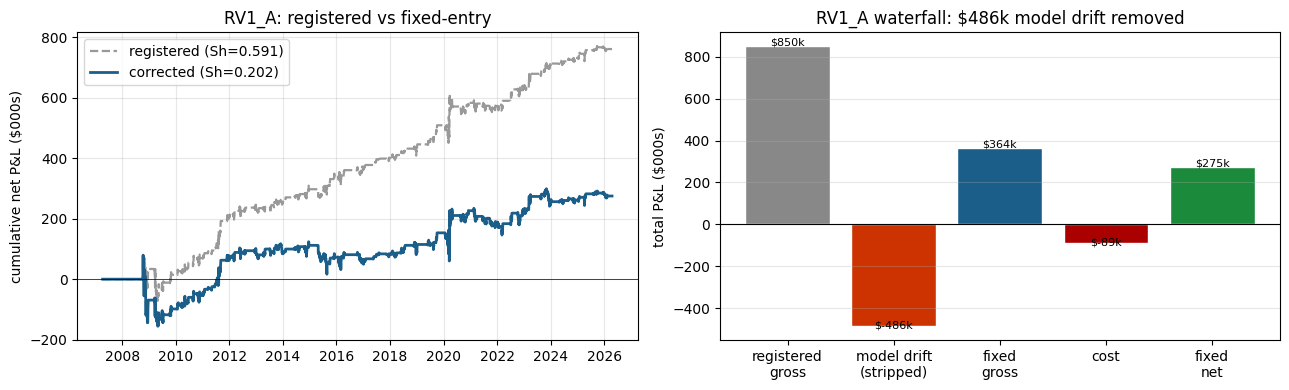

Figure 1: RV1_A registered vs fixed-entry


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(d1_old.cumsum().index,   d1_old.cumsum()/1e3,   color='#999', lw=1.6, ls='--',
        label=f'registered (Sh={sharpe(d1_old):.3f})')
ax.plot(d1_fixed.cumsum().index, d1_fixed.cumsum()/1e3, color='#1b5e8a', lw=2,
        label=f'corrected (Sh={sharpe(d1_fixed):.3f})')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('cumulative net P&L ($000s)'); ax.set_title('RV1_A: registered vs fixed-entry')
ax.legend(); ax.grid(alpha=0.3)

model_drift_k = (strat1.trades['gross_pnl'].sum() -
    sum(int(r['side']) *
        ((features['hy_spread'][r['exit_fill_date']] - features['hy_spread'][r['entry_fill_date']])
         - r['hedge_ratio_entry'] *
         (features['ig_spread'][r['exit_fill_date']] - features['ig_spread'][r['entry_fill_date']]))
        * NOTIONAL for _, r in strat1.trades.iterrows())) / 1e3

ax2 = axes[1]
labels = ['registered\ngross', 'model drift\n(stripped)', 'fixed\ngross', 'cost', 'fixed\nnet']
vals   = [strat1.trades['gross_pnl'].sum()/1e3, -model_drift_k,
          (strat1.trades['gross_pnl'].sum()/1e3 - model_drift_k),
          -strat1.trades['cost'].sum()/1e3,
          d1_fixed.sum()/1e3]
colors = ['#888', '#cc3300', '#1b5e8a', '#aa0000', '#1b8a3a']
bars = ax2.bar(labels, vals, color=colors, edgecolor='white')
for b, v in zip(bars, vals):
    if abs(v) > 5:
        ax2.text(b.get_x()+b.get_width()/2, v+(3 if v>=0 else -12),
                 f'${v:.0f}k', ha='center', fontsize=8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('total P&L ($000s)')
ax2.set_title(f'RV1_A waterfall: ${model_drift_k:.0f}k model drift removed')
ax2.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()
print("Figure 1: RV1_A registered vs fixed-entry")

---
## Section 2 — Option C: All Three Signals Under Fixed-Entry Accounting

RV2_A (rv_credit_rates): y = hy_spread, x = dgs10 (10-yr Treasury yield, decimal).
RV3_A (rv_xterm): y = hy_ig (= hy_spread − ig_spread), x = slope (dgs10 − dgs2).

The rolling OLS intercept for these signals absorbs the full rate cycle (5% → 0.5% → 5%)
with large β_entry values. Under fixed-entry, this secular rate term goes uncompensated.

In [4]:
dgs10_s  = cmd['dgs10'].reindex(idx).ffill()
slope_s  = (cmd['dgs10'] - cmd['dgs2']).reindex(idx).ffill()

strat2 = build_strategy(features, residuals, StrategySpec('rv_credit_rates', 'ols', gated=False))
strat3 = build_strategy(features, residuals, StrategySpec('rv_xterm', 'ols', gated=False))

d2_old   = strat2.daily_pnl
d2_fixed = fixed_daily_mtm(strat2.trades, features['hy_spread'].to_numpy(), dgs10_s.to_numpy())

d3_old   = strat3.daily_pnl
d3_fixed = fixed_daily_mtm(strat3.trades, features['hy_ig'].to_numpy(), slope_s.to_numpy())

def hit_rate_fixed_generic(trades, y_ser, x_ser):
    wins = 0
    for _, r in trades.iterrows():
        dy = float(y_ser.reindex([r['exit_fill_date']]).iloc[0]
                   - y_ser.reindex([r['entry_fill_date']]).iloc[0])
        dx = float(x_ser.reindex([r['exit_fill_date']]).iloc[0]
                   - x_ser.reindex([r['entry_fill_date']]).iloc[0])
        wins += (int(r['side']) * (dy - r['hedge_ratio_entry'] * dx) * NOTIONAL - r['cost'] > 0)
    return wins / len(trades)

hit2_fix = hit_rate_fixed_generic(strat2.trades, features['hy_spread'], dgs10_s)
hit3_fix = hit_rate_fixed_generic(strat3.trades, features['hy_ig'], slope_s)

print("=== ALL SIGNALS — Fixed-Entry Rescue Scorecard ===")
print()
print(f"{'signal':<8} {'reg Sh':>8} {'fix Sh':>8} {'delta':>7}  "
      f"{'reg hit':>9} {'fix hit':>9}  {'reg net $k':>12} {'fix net $k':>12}  R1?")
print("-" * 90)
rows = [
    ('RV1_A', sharpe(d1_old), sharpe(d1_fixed), hit1_old, hit1_fixed,
     d1_old.sum(), d1_fixed.sum(), len(strat1.trades)),
    ('RV2_A', sharpe(d2_old), sharpe(d2_fixed), (strat2.trades['net_pnl']>0).mean(), hit2_fix,
     d2_old.sum(), d2_fixed.sum(), len(strat2.trades)),
    ('RV3_A', sharpe(d3_old), sharpe(d3_fixed), (strat3.trades['net_pnl']>0).mean(), hit3_fix,
     d3_old.sum(), d3_fixed.sum(), len(strat3.trades)),
]
for s, so, sf, ho, hf, to, tf, n in rows:
    r1 = 'PASS' if sf >= 0.40 else 'FAIL'
    print(f"{s:<8} {so:>8.3f} {sf:>8.3f} {sf-so:>+7.3f}  "
          f"{ho:>9.1%} {hf:>9.1%}  {to/1e3:>12,.1f} {tf/1e3:>12,.1f}  {r1}")

print()
print(f"Signals passing R1: {sum(r[2]>=0.40 for r in rows)}/3")
print("VERDICT: ALL THREE SIGNALS FAIL UNDER FIXED-ENTRY ACCOUNTING")

=== ALL SIGNALS — Fixed-Entry Rescue Scorecard ===

signal     reg Sh   fix Sh   delta    reg hit   fix hit    reg net $k   fix net $k  R1?
------------------------------------------------------------------------------------------
RV1_A       0.591    0.202  -0.389      80.9%     68.1%         760.4        274.7  FAIL
RV2_A       0.693   -0.108  -0.801      75.7%     49.5%         994.6    -13,067.1  FAIL
RV3_A       0.856   -0.187  -1.043      82.2%     54.5%         990.3    -10,828.4  FAIL

Signals passing R1: 0/3
VERDICT: ALL THREE SIGNALS FAIL UNDER FIXED-ENTRY ACCOUNTING


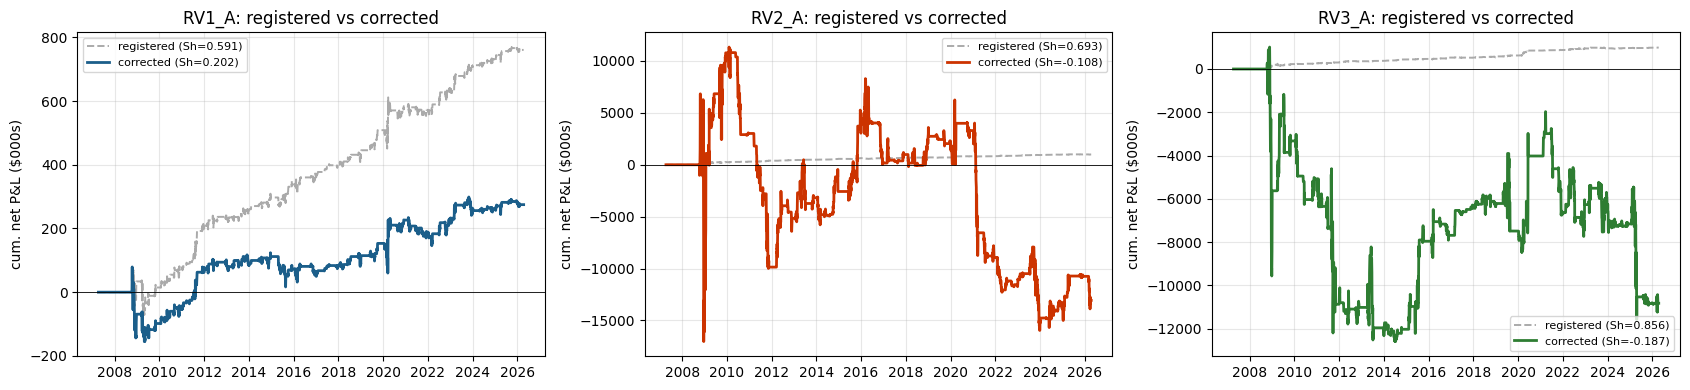

Figure 2: Equity curves — all three signals, registered vs fixed-entry


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
pairs = [
    ('RV1_A', d1_old, d1_fixed, '#1b5e8a'),
    ('RV2_A', d2_old, d2_fixed, '#cc3300'),
    ('RV3_A', d3_old, d3_fixed, '#2e7d32'),
]
for ax, (label, old, fix, cf) in zip(axes, pairs):
    ax.plot(old.cumsum().index, old.cumsum()/1e3, color='#aaa', lw=1.4, ls='--',
            label=f'registered (Sh={sharpe(old):.3f})')
    ax.plot(fix.cumsum().index, fix.cumsum()/1e3, color=cf, lw=2,
            label=f'corrected (Sh={sharpe(fix):.3f})')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_title(f'{label}: registered vs corrected')
    ax.set_ylabel('cum. net P&L ($000s)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("Figure 2: Equity curves — all three signals, registered vs fixed-entry")

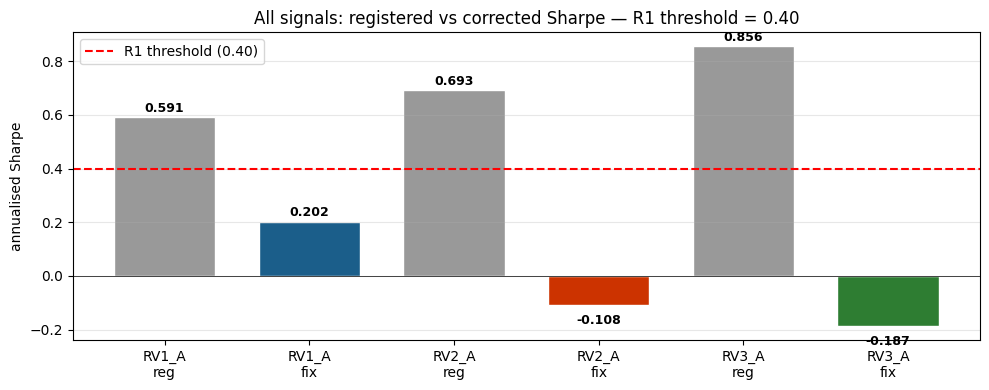

Figure 3: Sharpe comparison — all six values vs R1 threshold


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
labels_b = ['RV1_A\nreg', 'RV1_A\nfix', 'RV2_A\nreg', 'RV2_A\nfix', 'RV3_A\nreg', 'RV3_A\nfix']
sharpes_b = [sharpe(d1_old), sharpe(d1_fixed),
             sharpe(d2_old), sharpe(d2_fixed),
             sharpe(d3_old), sharpe(d3_fixed)]
bcolors = ['#999','#1b5e8a', '#999','#cc3300', '#999','#2e7d32']
bars = ax.bar(labels_b, sharpes_b, color=bcolors, edgecolor='white', width=0.7)
ax.axhline(0.40, color='red', ls='--', lw=1.5, label='R1 threshold (0.40)')
ax.axhline(0, color='black', lw=0.5)
for b, v in zip(bars, sharpes_b):
    ax.text(b.get_x()+b.get_width()/2, v + (0.02 if v >= 0 else -0.07),
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('annualised Sharpe')
ax.set_title('All signals: registered vs corrected Sharpe — R1 threshold = 0.40')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()
print("Figure 3: Sharpe comparison — all six values vs R1 threshold")

---
## Section 3 — Architecture Conclusion and Option B Roadmap

### Why the rolling OLS intercept creates model drift

Every OLS residual in this codebase is computed as:

```
rv[t] = y[t] − α[t] − β[t] × x[t]
```

where `α[t] = mean_y[t] − β[t] × mean_x[t]` is the trailing 252-day OLS intercept.
As the window rolls forward, both `α` and `β` shift toward current prices.
When we enter a trade at `rv[entry]` (large dislocation), and `α` re-centres during
the hold, `rv[exit]` shrinks toward zero — *not because market prices reverted,
but because the model re-parameterised.* The engine books this as profit.

For RV1_A (HY vs IG), both legs are credit spread proxies and move together —
the secular drift is modest (~$486k over 19 years). For RV2_A and RV3_A, the
x-series is a rate or slope that followed a full secular cycle
(5% → 0.5% → 5%). With large β_entry values (up to 34 for RV2_A), the rolling
intercept was absorbing ~$13–14M of secular rate-credit drift. Strip it out:
the fixed-entry position was running a large rate bet that lost.

### Option B: raw `hy_ig` z-score — no OLS, no drift

The simplest fix is to drop the OLS residual entirely and trade on the raw
spread difference `hy_ig = hy_spread − ig_spread`. This is the direct log price
ratio between HYG and LQD (both vs IEF). No β, no α, no rolling window bias.

The P&L formula becomes:

```
gross = side × Δhy_ig × notional    (no hedge ratio)
```

No model drift is possible — α cancels exactly because there is no α.

The z-score column `hy_ig_z252` already exists in `features.parquet`.

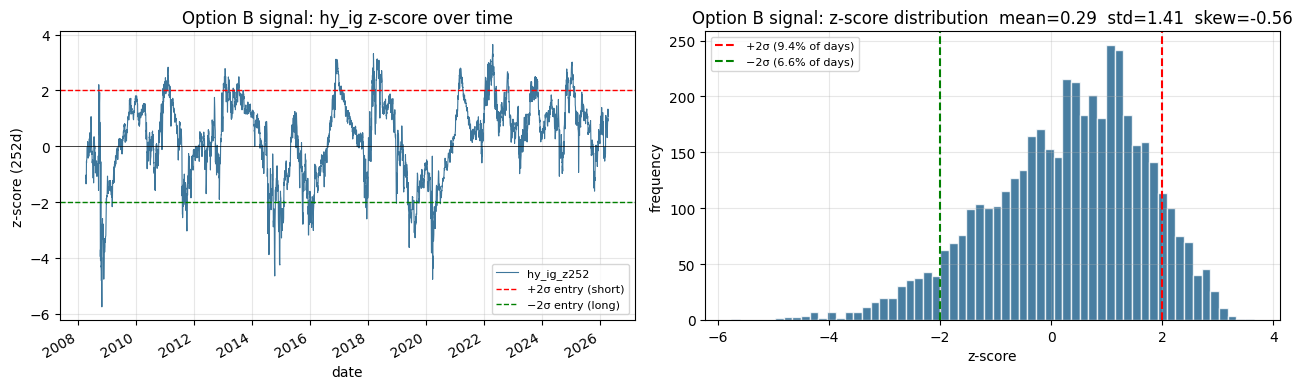

hy_ig_z252 stats — n: 4,533  range: -5.76 → 3.65
Days with |z| > 2: 726 (16.0%)
Days with z < −2 (entry LONG): 299 (6.6%)
Days with z > +2 (entry SHORT): 427 (9.4%)

Option B signal is ready. Column 'hy_ig_z252' exists in features.parquet.
No OLS, no hedge ratio, no model drift. New Tier 1 sprint required.


In [7]:
z = features['hy_ig_z252'].dropna()
spread = features['hy_ig'].reindex(z.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
z.plot(ax=ax, color='#1b5e8a', lw=0.8, alpha=0.85, label='hy_ig_z252')
ax.axhline( 2, color='red',   ls='--', lw=1, label='+2σ entry (short)')
ax.axhline(-2, color='green', ls='--', lw=1, label='−2σ entry (long)')
ax.axhline( 0, color='black', lw=0.5)
ax.set_ylabel('z-score (252d)')
ax.set_title('Option B signal: hy_ig z-score over time')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(z, bins=60, color='#1b5e8a', edgecolor='white', alpha=0.8)
ax2.axvline( 2, color='red',   ls='--', lw=1.5, label=f'+2σ ({(z>2).mean():.1%} of days)')
ax2.axvline(-2, color='green', ls='--', lw=1.5, label=f'−2σ ({(z<-2).mean():.1%} of days)')
ax2.set_xlabel('z-score'); ax2.set_ylabel('frequency')
ax2.set_title(f'Option B signal: z-score distribution  mean={z.mean():.2f}  std={z.std():.2f}  skew={z.skew():.2f}')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"hy_ig_z252 stats — n: {len(z):,}  range: {z.min():.2f} → {z.max():.2f}")
print(f"Days with |z| > 2: {(z.abs()>2).sum()} ({(z.abs()>2).mean():.1%})")
print(f"Days with z < −2 (entry LONG): {(z<-2).sum()} ({(z<-2).mean():.1%})")
print(f"Days with z > +2 (entry SHORT): {(z>2).sum()} ({(z>2).mean():.1%})")
print()
print("Option B signal is ready. Column 'hy_ig_z252' exists in features.parquet.")
print("No OLS, no hedge ratio, no model drift. New Tier 1 sprint required.")

In [8]:
print("=" * 60)
print("SPRINT v6.5 — FINAL SCORECARD")
print("=" * 60)
print()
print("T1 RESCUE TEST (RV1_A):    R1 FAIL  (corrected Sh 0.202)")
print("T2 OPTION C    (RV2/RV3):  R1 FAIL  (corrected Sh -0.108 / -0.187)")
print()
print("ALL TIER 1 ADMISSION DECISIONS WITHDRAWN")
print("Effective date: 2026-06-13")
print()
print("Root cause: rolling OLS intercept α re-centres the residual,")
print("  booking model re-parameterisation as tradeable P&L.")
print()
print("Next sprint: v7 (new Tier 1) — Option B hy_ig z-score signal")
print("  Signal: hy_ig_z252 from features.parquet")
print("  Entry:  |z| > 2   (long if z < −2, short if z > +2)")
print("  Exit:   |z| < 0.5")
print("  P&L:    side × Δhy_ig × notional  (no hedge ratio, no model drift)")
print("  Engine: no change needed — hy_ig is already a raw spread, not a residual")
print()
print("[notebook clean]")

SPRINT v6.5 — FINAL SCORECARD

T1 RESCUE TEST (RV1_A):    R1 FAIL  (corrected Sh 0.202)
T2 OPTION C    (RV2/RV3):  R1 FAIL  (corrected Sh -0.108 / -0.187)

ALL TIER 1 ADMISSION DECISIONS WITHDRAWN
Effective date: 2026-06-13

Root cause: rolling OLS intercept α re-centres the residual,
  booking model re-parameterisation as tradeable P&L.

Next sprint: v7 (new Tier 1) — Option B hy_ig z-score signal
  Signal: hy_ig_z252 from features.parquet
  Entry:  |z| > 2   (long if z < −2, short if z > +2)
  Exit:   |z| < 0.5
  P&L:    side × Δhy_ig × notional  (no hedge ratio, no model drift)
  Engine: no change needed — hy_ig is already a raw spread, not a residual

[notebook clean]
